# LDH Adsorption – RR % Modeling (dataset 2026-08-04)
**Dataset:** micropollutant adsorption on LDH (Layered Double Hydroxide) materials — `Data/20260804_Data_Adsorption.xlsx`

**Goal:** predict RR % for studied LDH–pollutant systems at new operating conditions (LR, KNN, ANN, Cubist, RF, XGB, HistGB), with honest train/CV/test reporting and feature-importance analysis.

> **Scope of the claim.** The dataset's 1342 rows come from **59 source studies**: within one
> study, the material and pollutant descriptors are constant and only the operating conditions
> (pH, temperature, time, dosage, Ci) vary. These models are therefore trained and validated to
> **predict RR % for *studied* material–pollutant systems at new operating conditions**
> (within-system interpolation, row-level split with exact-duplicate rows removed).
> They are **not** validated for screening unseen materials or pollutants: a grouped split by
> source study (reported in the main notebook as a limitation analysis) shows near-zero
> cross-study R². Do not cite the interpolation metrics as evidence of screening power.

> **Methodology notes (rewrite, 2026-09):** rebuilt on the shared
> [`ldh_pipeline.py`](ldh_pipeline.py) module after a code review. Scores are reported as three
> honestly-labeled numbers (train / CV validation / hold-out test); KNN imputation, scaling and
> encoding live inside each model's Pipeline (fit on training folds only); RR % is normalized
> range-aware to [0, 100]; exact feature-duplicate rows are removed before splitting; every
> split, CV fold, and Optuna sampler is seeded; each experiment saves models + scores + config
> under its own `Model/<experiment_name>/` folder.

## 1. Setup & load

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
# On Colab: clone/mount the repo and point this at its notebooks/ folder.
sys.path.insert(0, str(Path.cwd()))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ldh_pipeline as lp

plt.rcParams.update({
    'figure.facecolor': '#F8F9FA', 'axes.facecolor': '#FAFAFA',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titleweight': 'bold', 'axes.titlesize': 12,
})
SEED = lp.SEED
print('Data dir :', lp.DATA_DIR)
print('Model dir:', lp.MODEL_DIR)

Data dir : D:\Research_Projects\GreenX_BaoTien_project\Data
Model dir: D:\Research_Projects\GreenX_BaoTien_project\Model


In [2]:
df = lp.load_data(lp.DATA_DIR / '20260804_Data_Adsorption.xlsx')
print(f"Shape: {df.shape}")
print(f"Source studies (Id): {df['Id'].nunique()}")
print(f"RR % range: [{df['RR %'].min():.2f}, {df['RR %'].max():.2f}]")
df.head()

Shape: (1342, 32)
Source studies (Id): 59
RR % range: [0.00, 100.00]


,Id,TP,Log Kow,MW g/mol,E,S,A,B,V,TSPA,...,BET m2/g,PV cm3/g,APD nm,pHpzc,pH,Tem,Time h,AD g/L,Ci mg/L,RR %
0,Amir M. Ramezani_2024,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,181.62,...,45.17,0.524,46.37,6.9,6.0,25.0,1.000000,0.4,50.0,68.0
1,Amir M. Ramezani_2024,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,181.62,...,45.17,0.524,46.37,6.9,6.0,25.0,0.083333,0.4,50.0,12.0
2,Amir M. Ramezani_2024,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,181.62,...,45.17,0.524,46.37,6.9,6.0,25.0,0.166667,0.4,50.0,20.0
3,Amir M. Ramezani_2024,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,181.62,...,45.17,0.524,46.37,6.9,6.0,25.0,0.250000,0.4,50.0,36.0
4,Amir M. Ramezani_2024,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,181.62,...,45.17,0.524,46.37,6.9,6.0,25.0,0.333333,0.4,50.0,45.6


## 2. Missing values

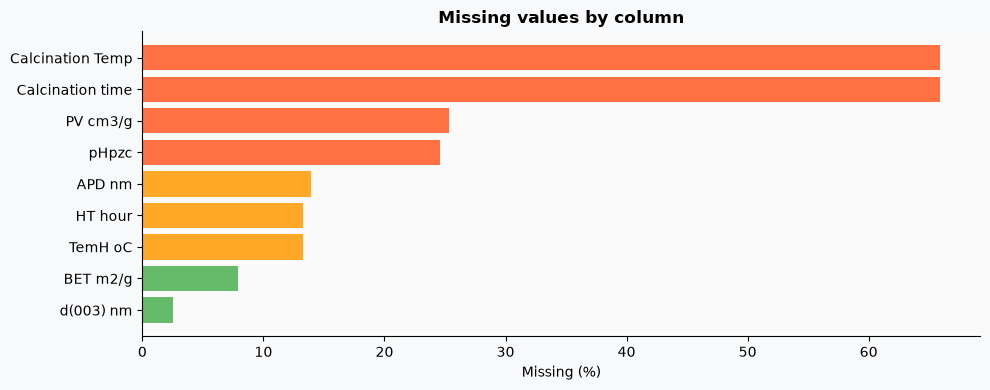

In [3]:
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(1)
miss_df = pd.DataFrame({'Missing count': miss, 'Missing %': miss_pct})
miss_df = miss_df[miss_df['Missing count'] > 0].sort_values('Missing %')
if len(miss_df):
    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ['#FF7043' if v > 20 else '#FFA726' if v > 10 else '#66BB6A'
              for v in miss_df['Missing %']]
    ax.barh(miss_df.index, miss_df['Missing %'], color=colors)
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing values by column')
    plt.tight_layout(); plt.show()
else:
    print('No missing values')

## 3. EDA – target by pollutant and by study

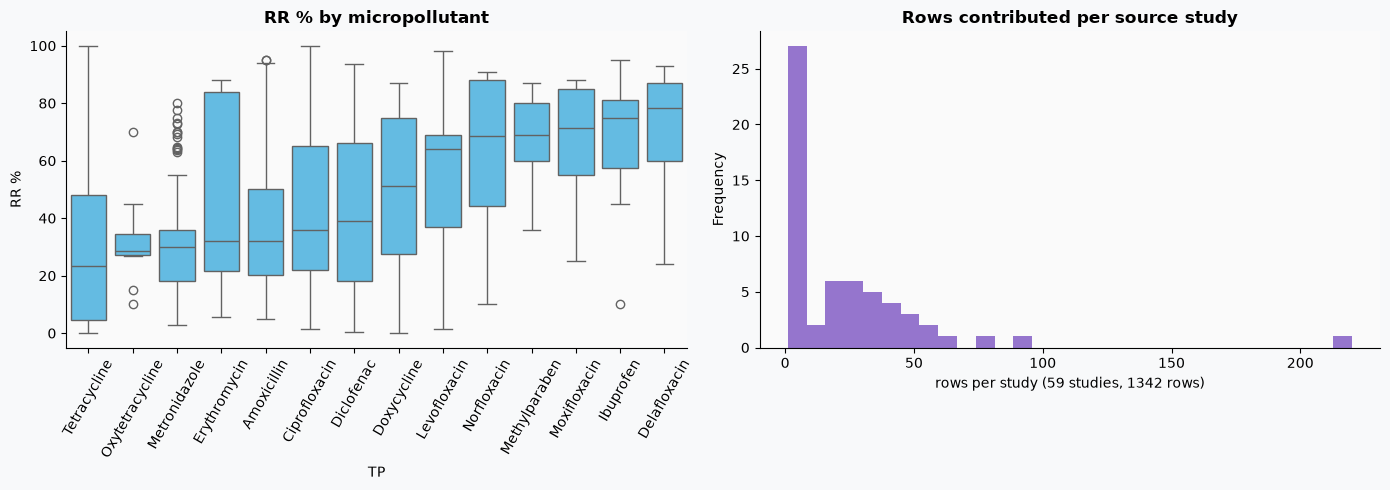

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = df.groupby('TP')['RR %'].median().sort_values().index
sns.boxplot(data=df, x='TP', y='RR %', order=order, ax=axes[0], color='#4FC3F7')
axes[0].set_title('RR % by micropollutant')      # (old version mislabeled this as Qe mg/g)
axes[0].tick_params(axis='x', rotation=60)
df['Id'].value_counts().plot.hist(bins=30, ax=axes[1], color='#9575CD')
axes[1].set_title('Rows contributed per source study')
axes[1].set_xlabel('rows per study (59 studies, 1342 rows)')
plt.tight_layout(); plt.show()

## 4. Multicollinearity (VIF)
Computed over features only — the previous version included the targets in the regressions, which contaminated the drop decisions.

In [5]:
X_all = df.drop(columns=['Id', 'RR %'])
lp.vif_table(X_all).head(15)

d:\Research_Projects\GreenX_BaoTien_project\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
d:\Research_Projects\GreenX_BaoTien_project\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
d:\Research_Projects\GreenX_BaoTien_project\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
d:\Research_Projects\GreenX_BaoTien_project\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely d

,feature,VIF
0,HT hour,727638.251429
1,A,492730.196647
2,TSPA,104888.457558
3,TemH oC,100557.828186
4,d(003) nm,89580.009675
5,Calcination Temp,38486.751963
6,M(II)/(III),35897.817699
7,APD nm,34476.510382
8,PV cm3/g,24728.447149
9,average d-electron,23880.202452


## 5. Experiments
Feature sets are named configs; every run saves its models, scores, and config under
`Model/<name>/`.

- **interp_row_42** — PRIMARY: all features, row-level split (within-system interpolation),
  exact-duplicate rows removed.
- **corr_drop_interp_42** — same protocol, dropping the highly-correlated descriptor block
  (the old "Experiment 2").
- **generalization_group_42** — LIMITATION ANALYSIS: identical models under a split grouped by
  source study; measures prediction on *unseen* studies.

In [6]:
MODELS = ("LR", "KNN", "ANN", "Cubist", "RF", "XGB", "LGB", "HistGB")

experiments = {
    'interp_row_42': lp.ExperimentConfig(
        name='interp_row_42', split_mode='row', dedup_features=True, models=MODELS),
    'generalization_group_42': lp.ExperimentConfig(
        name='generalization_group_42', split_mode='group', dedup_features=True, models=MODELS),
}
runs = {}
for name, cfg in experiments.items():
    print(f"\n================ {name} ================")
    runs[name] = lp.run_experiment(cfg, df)


================ interp_row_42 ================
[interp_row_42] dropped 83 exact feature-duplicate rows
[interp_row_42] split=row  train=1007  test=252  features=30
[BorutaShap] Starting feature selection...


  0%|          | 0/20 [00:00<?, ?it/s]

[BorutaShap] Suggested dropping 10 features.
[BorutaShap] OVERRIDE: Saved 3 Abraham variable(s) from being dropped.
[BorutaShap] Final number of features dropping: 7
[interp_row_42] Features remaining after BorutaShap: 23
--- Optuna tuning RF (30 trials) ---
[*] RF best params: {'n_estimators': 139, 'max_depth': 15, 'min_samples_leaf': 3}
--- Optuna tuning XGB (30 trials) ---
[*] XGB best params: {'n_estimators': 374, 'learning_rate': 0.17744024928675656, 'max_depth': 11, 'min_child_weight': 7}
--- Optuna tuning HistGB (30 trials) ---
[*] HistGB best params: {'max_iter': 396, 'learning_rate': 0.11006707150516844, 'max_depth': 12, 'min_samples_leaf': 3}
--- Optuna tuning LGB (30 trials) ---
[*] LGB best params: {'n_estimators': 319, 'learning_rate': 0.10786845740314342, 'max_depth': 13, 'min_child_samples': 7}
--- LR ---
    Train      R2  0.3986 | MAE  17.6757
    CV (valid) R2  0.3545 | MAE  18.1776
    Test       R2  0.4068 | MAE  18.2030

--- KNN ---
[*] best params: {'n_neighbors':

  0%|          | 0/20 [00:00<?, ?it/s]

[BorutaShap] Suggested dropping 11 features.
[BorutaShap] OVERRIDE: Saved 2 Abraham variable(s) from being dropped.
[BorutaShap] Final number of features dropping: 9
[generalization_group_42] Features remaining after BorutaShap: 21
--- Optuna tuning RF (30 trials) ---
[*] RF best params: {'n_estimators': 192, 'max_depth': 15, 'min_samples_leaf': 3}
--- Optuna tuning XGB (30 trials) ---
[*] XGB best params: {'n_estimators': 290, 'learning_rate': 0.1450068557874677, 'max_depth': 3, 'min_child_weight': 9}
--- Optuna tuning HistGB (30 trials) ---
[*] HistGB best params: {'max_iter': 348, 'learning_rate': 0.04879160194371968, 'max_depth': 3, 'min_samples_leaf': 9}
--- Optuna tuning LGB (30 trials) ---
[*] LGB best params: {'n_estimators': 536, 'learning_rate': 0.2044920808385466, 'max_depth': 6, 'min_child_samples': 8}
--- LR ---
    Train      R2  0.5168 | MAE  16.1364
    CV (valid) R2 -1.7747 | MAE  34.0051
    Test       R2 -2.7638 | MAE  36.9751

--- KNN ---
[*] best params: {'n_neighb

## 6. Results — primary (within-system interpolation)

In [8]:
print("=== interp_row_42 (PRIMARY) ===")
print(runs['interp_row_42']['table'].round(3))

=== interp_row_42 (PRIMARY) ===
        train_r2  cv_r2  test_r2  train_mae  cv_mae  test_mae  test_rmse
HistGB     0.995  0.837    0.877      1.017   6.766     5.169      9.883
LGB        0.984  0.835    0.886      1.960   7.016     5.287      9.540
XGB        0.991  0.836    0.864      1.004   6.988     5.611     10.397
KNN        0.990  0.718    0.775      0.255   8.160     7.388     13.376
RF         0.901  0.772    0.800      5.749   9.093     8.293     12.630
Cubist     0.916  0.779    0.784      4.695   8.374     8.349     13.129
ANN        0.609  0.517    0.564     13.180  15.006    14.195     18.649
LR         0.399  0.354    0.407     17.676  18.178    18.203     21.742


### Limitation: cross-study generalization
Same data, same models, same preprocessing — but the test set holds entire unseen studies. The gap between the two columns bounds the claim: performance reflects interpolation within studied systems, not screening of new ones.

In [9]:
cmp = pd.DataFrame({
    'test_R2 (interpolation)': runs['interp_row_42']['table']['test_r2'],
    'test_R2 (unseen studies)': runs['generalization_group_42']['table']['test_r2'],
    'test_RMSE (interpolation)': runs['interp_row_42']['table']['test_rmse'],
    'test_RMSE (unseen studies)': runs['generalization_group_42']['table']['test_rmse'],
}).round(3)
cmp.to_csv(lp.MODEL_DIR / 'claim_scope_comparison.csv')
cmp

,test_R2 (interpolation),test_R2 (unseen studies),test_RMSE (interpolation),test_RMSE (unseen studies)
ANN,0.564,-1.141,18.649,36.515
Cubist,0.784,-0.334,13.129,28.824
HistGB,0.877,-0.101,9.883,26.188
KNN,0.775,-1.093,13.376,36.107
LGB,0.886,-0.841,9.540,33.860
LR,0.407,-2.764,21.742,48.420
RF,0.800,-0.420,12.630,29.738
XGB,0.864,-0.108,10.397,26.273


## 7. Best model – performance visualization

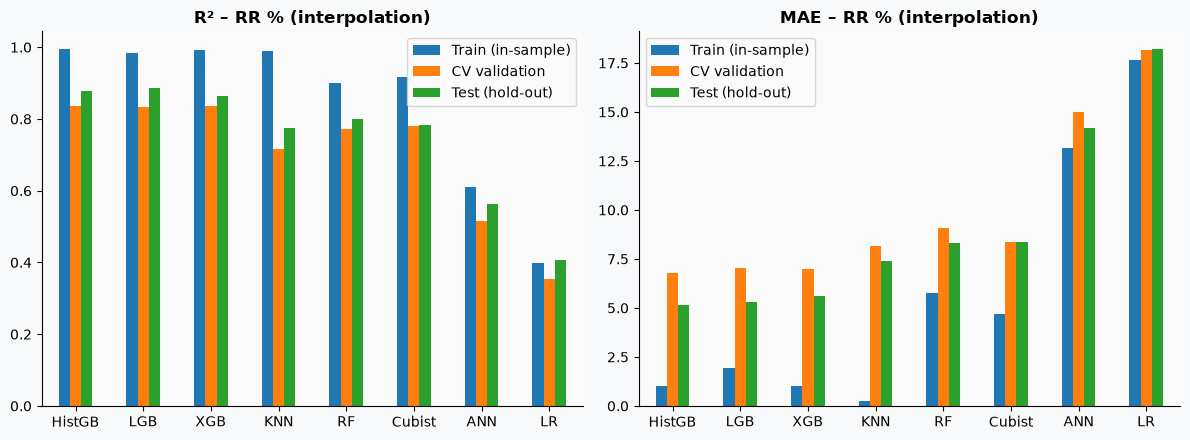

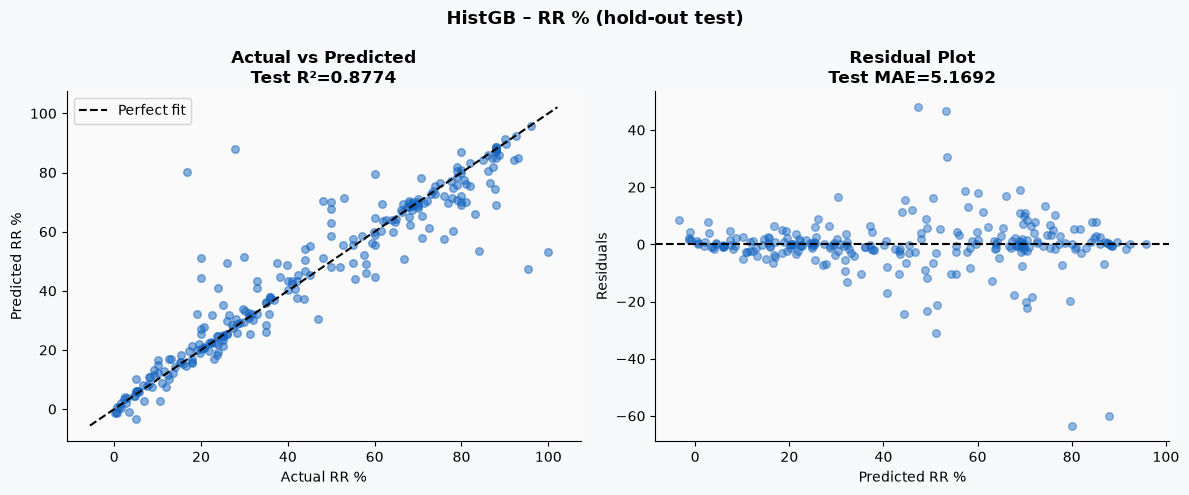

In [10]:
run = runs['interp_row_42']
lp.plot_model_comparison(run['table'], 'RR % (interpolation)',
                         out_path=run['out_dir'] / 'model_results.png')
best_name = run['table'].index[0]  # lowest test MAE
lp.plot_parity(run['results'][best_name], 'RR %',
               out_path=run['out_dir'] / 'best_model_parity.png')

## 8. Feature importance
Permutation importance and SHAP are computed with the already-fitted models on the hold-out test set.

In [11]:
ranks = lp.permutation_ranks(run['results'], run['X_test'], run['y_test'])
ranks.to_csv(run['out_dir'] / 'permutation_importance.csv')  # keeps feature index
ranks.sort_values('HistGB')

,LR,KNN,ANN,Cubist,RF,XGB,HistGB,LGB
AD g/L,13,1,23,1,1,1,1,1
Time h,11,2,2,2,2,2,2,2
Ci mg/L,17,4,16,3,3,3,3,3
pH,20,3,3,6,6,5,4,4
Log Kow,4,16,14,14,4,4,5,5
average Pauling electronegativity,10,10,6,11,9,6,6,9
BET m2/g,19,5,4,8,7,8,7,6
d(003) nm,5,6,1,7,11,7,8,10
pHpzc,23,7,15,9,5,10,9,7
PV cm3/g,18,18,8,4,8,12,10,8


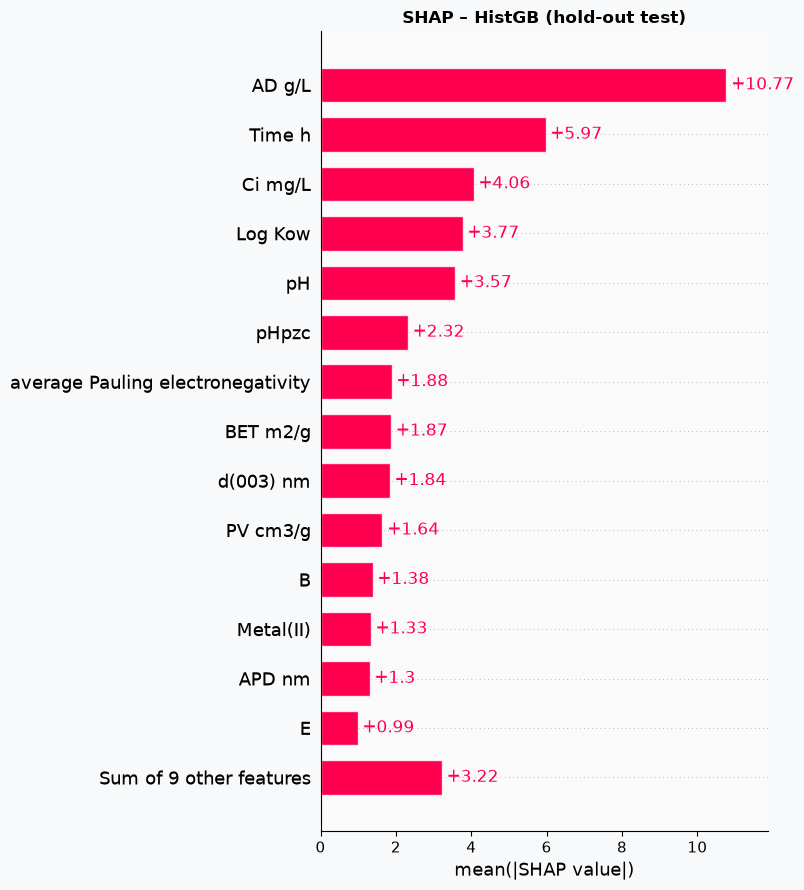

In [12]:
import shap
best_tree = run['table'].loc[run['table'].index.isin(['HistGB', 'XGB', 'RF'])].index[0]
sv, feat_names = lp.shap_summary(run['results'][best_tree], run['X_test'])
sv.feature_names = feat_names
shap.plots.bar(sv, max_display=15, show=False)
plt.title(f'SHAP – {best_tree} (hold-out test)')
plt.tight_layout()
plt.savefig(run['out_dir'] / 'shap_bar_plot.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Conclusions
- **Claim:** for material–pollutant systems present in the training data, the models predict RR % at new operating conditions with the accuracy shown in the primary table (tree ensembles lead).
- **Limitation (stated, quantified):** cross-study R² is near zero — these models do not yet transfer to unseen materials/pollutants; `Model/claim_scope_comparison.csv` documents the gap.
- Model files, scores, and configs for every experiment live in `Model/<name>/`.